<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Importation des bibliotheques</T1>

In [7]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from Mon_module import add_bands

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Chargement des donnees</T1>

In [2]:
# répertoire des données brutes :
data_dir = Path("..") / "data" / "cleaned"
csv_files = sorted([p for p in data_dir.iterdir()])

# liste de DataFrame et dict {stem: df} :
dfs = [pd.read_csv(p) for p in csv_files]
dfs_names = [p.stem for p in csv_files]
dfs_dict = dict(zip(dfs_names, dfs))

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Calcul des KPIs</T1>

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>KPI 1 : Volatilité rolling 30 jours</T1>

In [3]:
eur = dfs_dict['taux_change (EUR)_cleaned'].copy()
usd = dfs_dict['taux_change (USD)_cleaned'].copy()

eur['Date'] = pd.to_datetime(eur['Date'])
usd['Date'] = pd.to_datetime(usd['Date'])

eur = eur.sort_values('Date').set_index('Date')
usd = usd.sort_values('Date').set_index('Date')

# Volatilité rolling 30 jours (std des variations quotidiennes)
eur['KPI1_Vol_EUR'] = eur['Variation'].rolling(window=30, min_periods=15).std()
usd['KPI1_Vol_USD'] = usd['Variation'].rolling(window=30, min_periods=15).std()

# Agréger à l'année pour le fichier KPI consolidé
kpi1_eur = eur['KPI1_Vol_EUR'].resample('Y').mean().rename('KPI1_Vol_EUR_ann')
kpi1_usd = usd['KPI1_Vol_USD'].resample('Y').mean().rename('KPI1_Vol_USD_ann')

kpi1 = pd.concat([kpi1_eur, kpi1_usd], axis=1).reset_index()
kpi1['Year'] = kpi1['Date'].dt.year
kpi1 = kpi1.drop(columns='Date')

print("KPI 1 — Volatilité rolling 30 jours (moyenne annuelle) :")
display(kpi1)

KPI 1 — Volatilité rolling 30 jours (moyenne annuelle) :


,KPI1_Vol_EUR_ann,KPI1_Vol_USD_ann,Year
0,0.172423,0.612153,2010
1,0.154455,0.604794,2011
2,0.132155,0.428682,2012
3,0.123756,0.374852,2013
4,0.130273,0.322775,2014
5,0.270039,0.510012,2015
6,0.254402,0.341165,2016
7,0.232598,0.302431,2017
8,0.174096,0.278179,2018
9,0.172395,0.216653,2019


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1> KPI 2 : Variation annuelle du taux de change</T1>

In [4]:
eur_ann = (eur['Cours'].resample('Y').mean()
           .reset_index().rename(columns={'Date':'year','Cours':'EUR_MAD_moy'}))
usd_ann = (usd['Cours'].resample('Y').mean()
           .reset_index().rename(columns={'Date':'year','Cours':'USD_MAD_moy'}))

eur_ann['Year'] = eur_ann['year'].dt.year
usd_ann['Year'] = usd_ann['year'].dt.year

eur_ann['KPI2_Var_EUR'] = eur_ann['EUR_MAD_moy'].pct_change() * 100
usd_ann['KPI2_Var_USD'] = usd_ann['USD_MAD_moy'].pct_change() * 100

kpi2 = (eur_ann[['Year','EUR_MAD_moy','KPI2_Var_EUR']]
        .merge(usd_ann[['Year','USD_MAD_moy','KPI2_Var_USD']], on='Year'))

print("KPI 2 — Variation annuelle du taux de change :")
display(kpi2.round(4))

KPI 2 — Variation annuelle du taux de change :


,Year,EUR_MAD_moy,KPI2_Var_EUR,USD_MAD_moy,KPI2_Var_USD
0,2010,11.1596,NaN,8.4260,NaN
1,2011,11.2589,0.8898,8.0933,-3.9479
2,2012,11.0976,-1.4326,8.6349,6.6909
3,2013,11.1668,0.6237,8.4083,-2.6237
4,2014,11.1643,-0.0228,8.4148,0.0777
5,2015,10.8198,-3.0861,9.7499,15.8653
6,2016,10.8514,0.2925,9.8061,0.5768
7,2017,10.9552,0.9569,9.7075,-1.0060
8,2018,11.0822,1.1593,9.3891,-3.2793
9,2019,10.7613,-2.8958,9.6176,2.4328


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>KPI 3 & 4 : Balance commerciale et taux de couverture</T1>

KPI 3 & 4 — Balance commerciale et taux de couverture :


,Year,value_exports,value_imports,KPI3_Balance,KPI4_Tx_Couv
0,2024,6.745425e+10,8.060860e+10,-1.315436e+10,83.68
1,2023,6.194501e+10,7.404071e+10,-1.209570e+10,83.66
2,2022,5.868192e+10,7.375289e+10,-1.507097e+10,79.57
3,2021,4.706055e+10,6.019936e+10,-1.313881e+10,78.17
4,2020,3.736977e+10,4.617469e+10,-8.804922e+09,80.93
5,2019,4.395286e+10,5.402411e+10,-1.007125e+10,81.36
6,2018,4.307752e+10,5.529974e+10,-1.222222e+10,77.90
7,2017,3.865189e+10,4.927364e+10,-1.062175e+10,78.44
8,2016,3.429149e+10,4.506215e+10,-1.077066e+10,76.10
9,2015,3.311957e+10,4.117643e+10,-8.056862e+09,80.43


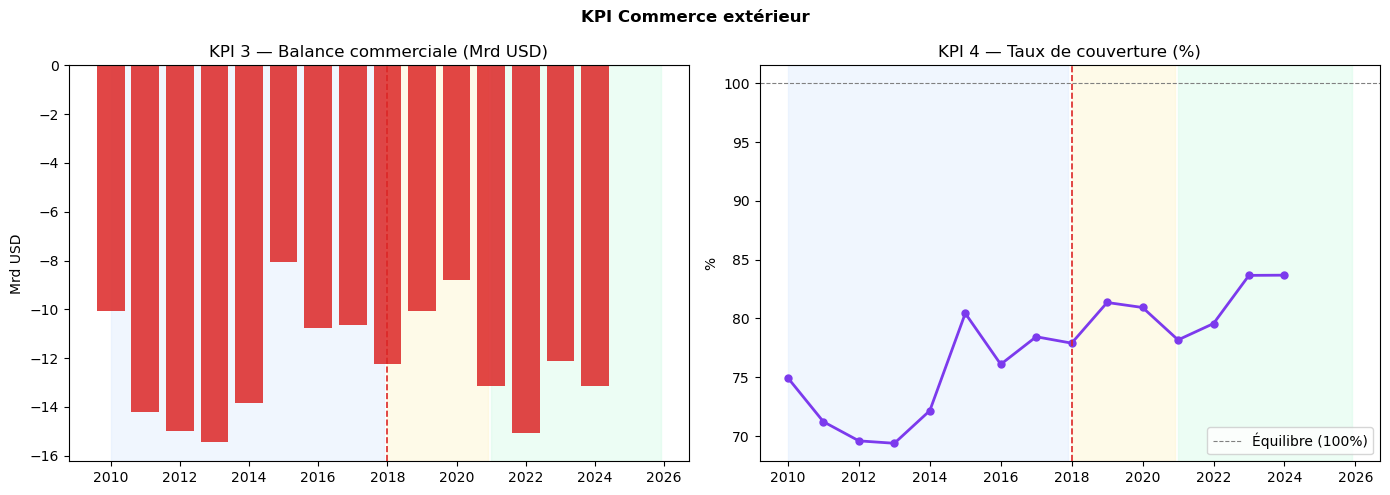

In [15]:
ice = dfs_dict['ice_global_cleaned'].copy()

ice['KPI3_Balance']    = ice['value_exports'] - ice['value_imports']
ice['KPI4_Tx_Couv']    = (ice['value_exports'] / ice['value_imports']) * 100

kpi34 = ice[['year','value_exports','value_imports',
             'KPI3_Balance','KPI4_Tx_Couv']].rename(columns={'year':'Year'})

print("KPI 3 & 4 — Balance commerciale et taux de couverture :")
display(kpi34.round(2))

# Visualisation rapide
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("KPI Commerce extérieur", fontweight='bold')

ax = axes[0]
ax.bar(kpi34['Year'], kpi34['KPI3_Balance']/1e9,
       color=['#DC2626' if v < 0 else '#1D9E75'
              for v in kpi34['KPI3_Balance']], alpha=0.85)
ax.axhline(0, color='gray', linewidth=0.8)
add_bands(ax, is_date=False)
ax.set_title("KPI 3 — Balance commerciale (Mrd USD)")
ax.set_ylabel("Mrd USD")

ax = axes[1]
ax.plot(kpi34['Year'], kpi34['KPI4_Tx_Couv'],
        color='#7C3AED', linewidth=2, marker='o', markersize=5)
ax.axhline(100, color='gray', linewidth=0.8,
           linestyle='--', label='Équilibre (100%)')
add_bands(ax, is_date=False)
ax.set_title("KPI 4 — Taux de couverture (%)")
ax.set_ylabel("%")
ax.legend()

plt.tight_layout()
plt.savefig("../visualisation/viz_kpi_commerce.png", bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>KPI 5 & 6 : IDE et variation</T1>

In [9]:
ide = dfs_dict['ide_global_cleaned'].copy()

kpi56 = ide[['Year','IDE_USD','FDI_growth_rate']].rename(columns={
    'IDE_USD':        'KPI5_IDE_USD',
    'FDI_growth_rate':'KPI6_Var_IDE'
})

print("KPI 5 & 6 — IDE et variation annuelle :")
display(kpi56.round(4))

KPI 5 & 6 — IDE et variation annuelle :


,Year,KPI5_IDE_USD,KPI6_Var_IDE
0,2024,1.639000e+09,NaN
1,2023,1.060024e+09,-35.3250
2,2022,2.294356e+09,116.4439
3,2021,2.264149e+09,-1.3166
4,2020,1.418713e+09,-37.3401
5,2019,1.720825e+09,21.2948
6,2018,3.544387e+09,105.9702
7,2017,2.680110e+09,-24.3844
8,2016,2.153364e+09,-19.6539
9,2015,3.252914e+09,51.0620


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1> KPI 7 : Taux d'inflation</T1>

In [10]:
ipc_c = dfs_dict['ipc_cleaned'].copy()

# Moyenne annuelle de l'IPC Ensemble
ipc_ann = (ipc_c.groupby('annee')['Ensemble']
           .mean().reset_index()
           .rename(columns={'annee':'Year','Ensemble':'IPC_moy'}))

# Variation annuelle = taux d'inflation
ipc_ann['KPI7_Inflation'] = ipc_ann['IPC_moy'].pct_change() * 100

print("KPI 7 — Taux d'inflation annuel :")
display(ipc_ann.round(4))

KPI 7 — Taux d'inflation annuel :


,Year,IPC_moy,KPI7_Inflation
0,2010,108.4250,NaN
1,2011,109.4083,0.9069
2,2012,110.8250,1.2948
3,2013,112.9000,1.8723
4,2014,113.4000,0.4429
5,2015,115.1667,1.5579
6,2016,117.0500,1.6353
7,2017,117.9333,0.7547
8,2018,120.0250,1.7736
9,2019,120.4250,0.3333


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>KPI 8 & 9 : Réserves</T1>

In [11]:
res = dfs_dict['reserves_cleaned'].copy()

kpi89 = res[['year','value_usd','value_months']].rename(columns={
    'year':         'Year',
    'value_usd':    'KPI8_Reserves_USD',
    'value_months': 'KPI9_Mois_Couv'
})

print("KPI 8 & 9 — Réserves de change :")
display(kpi89.round(4))

KPI 8 & 9 — Réserves de change :


,Year,KPI8_Reserves_USD,KPI9_Mois_Couv
0,2024,3.713391e+10,5.2712
1,2023,3.632770e+10,5.6348
2,2022,3.231425e+10,5.0621
3,2021,3.564827e+10,6.7713
4,2020,3.599764e+10,8.9354
5,2019,2.641276e+10,5.5842
6,2018,2.446102e+10,5.0451
7,2017,2.618959e+10,6.0253
8,2016,2.509626e+10,6.3379
9,2015,2.274957e+10,6.2580


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Consolidation de tous les KPI</T1>

In [ ]:
df_kpi = (kpi2[['Year','EUR_MAD_moy','USD_MAD_moy',
                 'KPI2_Var_EUR','KPI2_Var_USD']]
    .merge(kpi1,   on='Year', how='left')
    .merge(kpi34[['Year','KPI3_Balance','KPI4_Tx_Couv']], on='Year', how='left')
    .merge(kpi56,  on='Year', how='left')
    .merge(ipc_ann[['Year','KPI7_Inflation']], on='Year', how='left')
    .merge(kpi89,  on='Year', how='left')
)

# Ajouter la colonne période
def get_periode(y):
    if y <= 2017:   return 'Avant (2010-2017)'
    elif y <= 2020: return 'Transition (2018-2020)'
    else:           return 'Après (2021-2025)'

df_kpi['Periode'] = df_kpi['Year'].apply(get_periode)

# Réordonner les colonnes
cols_order = [
    'Year', 'Periode',
    'EUR_MAD_moy', 'USD_MAD_moy',
    'KPI1_Vol_EUR_ann', 'KPI1_Vol_USD_ann',
    'KPI2_Var_EUR', 'KPI2_Var_USD',
    'KPI3_Balance', 'KPI4_Tx_Couv',
    'KPI5_IDE_USD', 'KPI6_Var_IDE',
    'KPI7_Inflation',
    'KPI8_Reserves_USD', 'KPI9_Mois_Couv'
]
df_kpi = df_kpi[cols_order].sort_values('Year').reset_index(drop=True)

print(f"Fichier KPI consolidé : {df_kpi.shape}")
display(df_kpi.round(4))

# Sauvegarder
df_kpi.to_csv("../data/processed/kpis_maroc.csv", index=False, encoding='utf-8-sig')
print("Sauvegardé : data/processed/kpis_maroc.csv")

Fichier KPI consolidé : (17, 15)


,Year,Periode,EUR_MAD_moy,USD_MAD_moy,KPI1_Vol_EUR_ann,KPI1_Vol_USD_ann,KPI2_Var_EUR,KPI2_Var_USD,KPI3_Balance,KPI4_Tx_Couv,KPI5_IDE_USD,KPI6_Var_IDE,KPI7_Inflation,KPI8_Reserves_USD,KPI9_Mois_Couv
0,2010,Avant (2010-2017),11.1596,8.4260,0.1724,0.6122,NaN,NaN,-1.005030e+10,74.9350,1.240626e+09,-50.7954,NaN,2.370947e+10,7.2749
1,2011,Avant (2010-2017),11.2589,8.0933,0.1545,0.6048,0.8898,-3.9479,-1.421901e+10,71.2135,2.521362e+09,-11.2807,0.9069,2.016741e+10,4.9629
2,2012,Avant (2010-2017),11.0976,8.6349,0.1322,0.4287,-1.4326,6.6909,-1.500108e+10,69.5872,2.841954e+09,-15.4409,1.2948,1.713821e+10,4.1204
3,2013,Avant (2010-2017),11.1668,8.4083,0.1238,0.3749,0.6237,-2.6237,-1.545261e+10,69.3811,3.360910e+09,-4.6654,1.8723,1.879779e+10,4.5417
4,2014,Avant (2010-2017),11.1643,8.4148,0.1303,0.3228,-0.0228,0.0777,-1.385205e+10,72.1565,3.525385e+09,8.3762,0.4429,2.027205e+10,4.5776
5,2015,Avant (2010-2017),10.8198,9.7499,0.2700,0.5100,-3.0861,15.8653,-8.056862e+09,80.4333,3.252914e+09,51.0620,1.5579,2.274957e+10,6.2580
6,2016,Avant (2010-2017),10.8514,9.8061,0.2544,0.3412,0.2925,0.5768,-1.077066e+10,76.0982,2.153364e+09,-19.6539,1.6353,2.509626e+10,6.3379
7,2017,Avant (2010-2017),10.9552,9.7075,0.2326,0.3024,0.9569,-1.0060,-1.062175e+10,78.4433,2.680110e+09,-24.3844,0.7547,2.618959e+10,6.0253
8,2018,Transition (2018-2020),11.0822,9.3891,0.1741,0.2782,1.1593,-3.2793,-1.222222e+10,77.8982,3.544387e+09,105.9702,1.7736,2.446102e+10,5.0451
9,2019,Transition (2018-2020),10.7613,9.6176,0.1724,0.2167,-2.8958,2.4328,-1.007125e+10,81.3579,1.720825e+09,21.2948,0.3333,2.641276e+10,5.5842


Sauvegardé : data/processed/kpis_maroc.csv


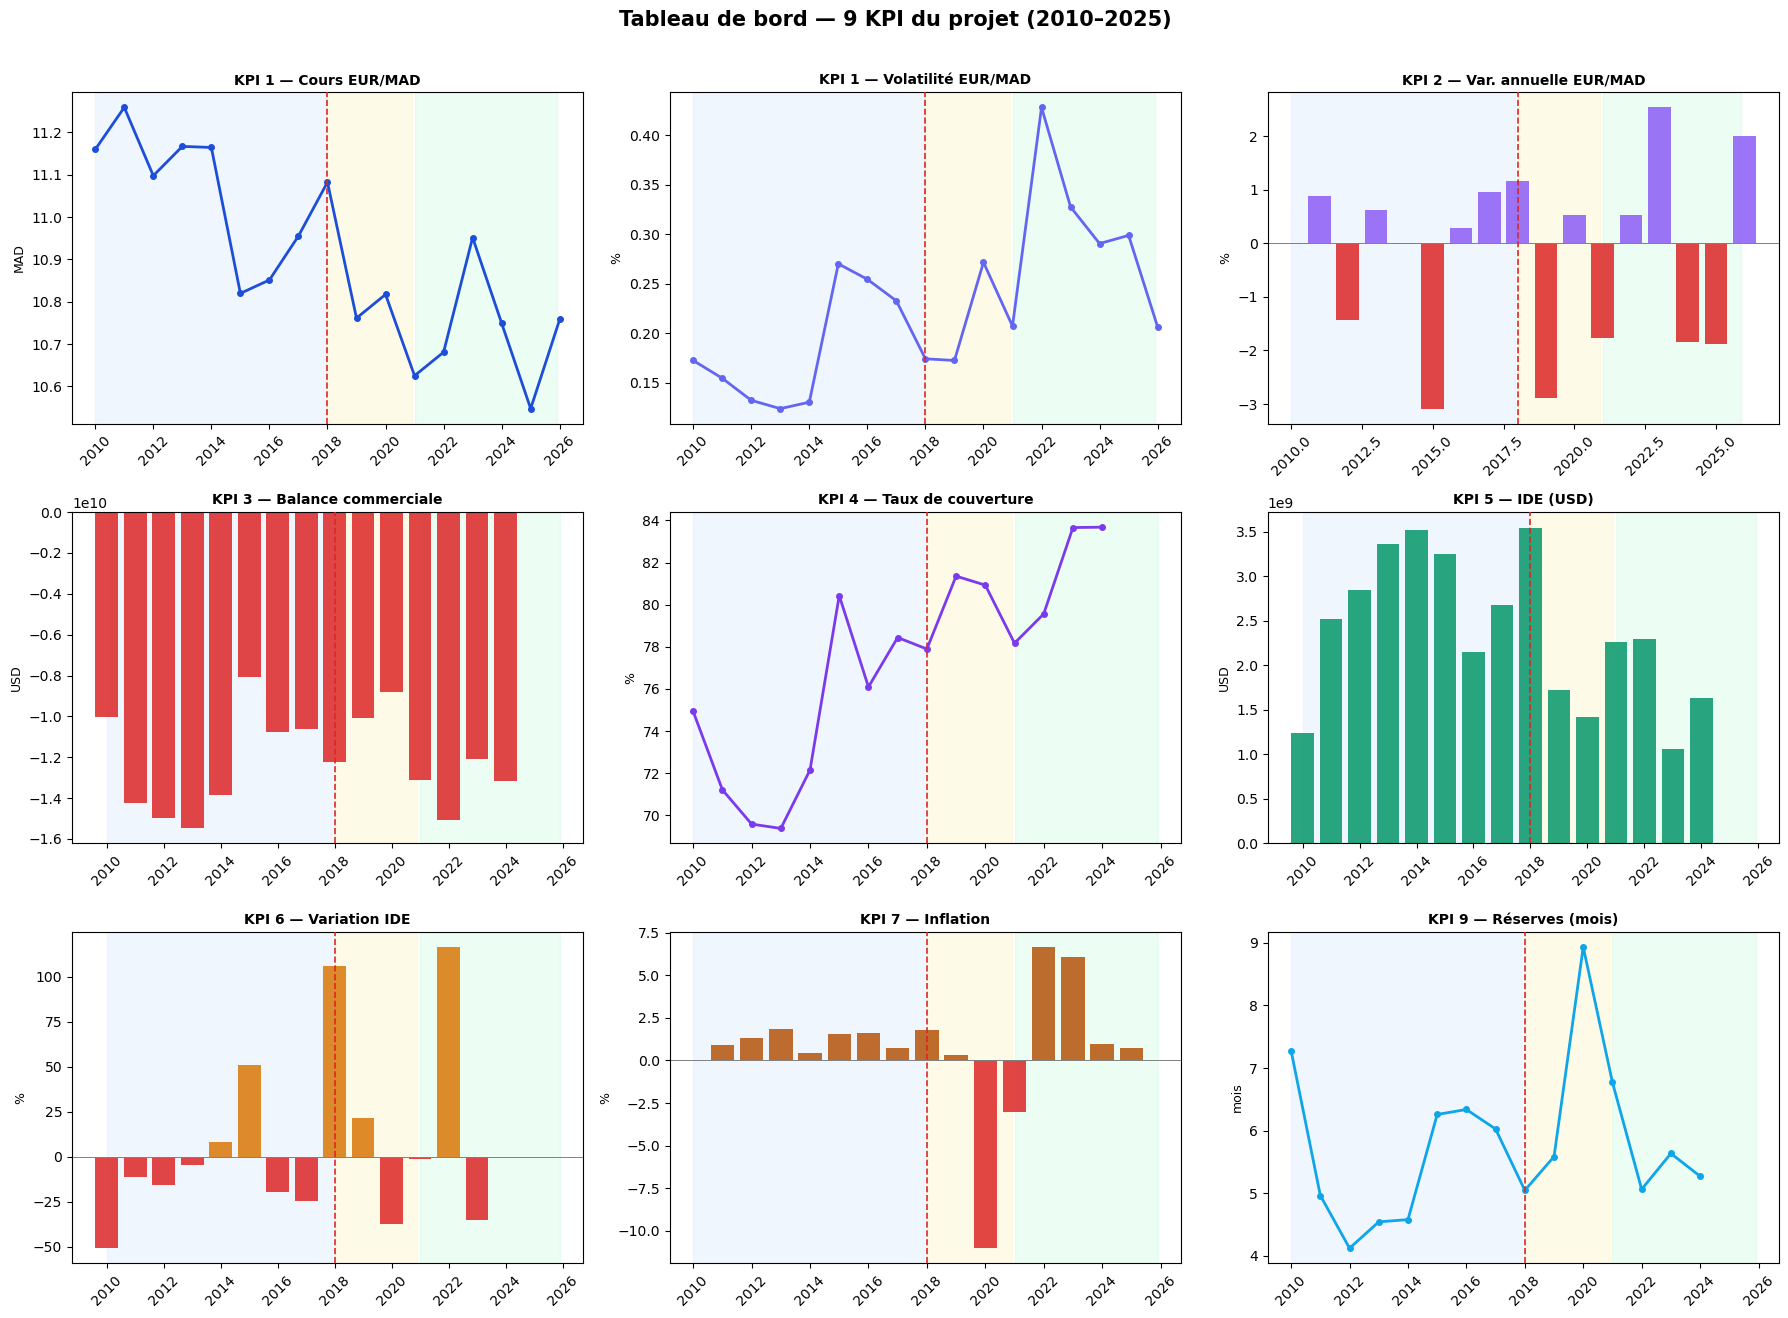

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
fig.suptitle("Tableau de bord — 9 KPI du projet (2010–2025)",
             fontsize=15, fontweight='bold', y=1.01)

kpis_viz = [
    (axes[0,0], 'Year', 'EUR_MAD_moy',       'KPI 1 — Cours EUR/MAD',          '#1D4ED8', 'line', 'MAD'),
    (axes[0,1], 'Year', 'KPI1_Vol_EUR_ann',   'KPI 1 — Volatilité EUR/MAD',     '#6366F1', 'line', '%'),
    (axes[0,2], 'Year', 'KPI2_Var_EUR',       'KPI 2 — Var. annuelle EUR/MAD',  '#8B5CF6', 'bar',  '%'),
    (axes[1,0], 'Year', 'KPI3_Balance',       'KPI 3 — Balance commerciale',    '#DC2626', 'bar',  'USD'),
    (axes[1,1], 'Year', 'KPI4_Tx_Couv',       'KPI 4 — Taux de couverture',     '#7C3AED', 'line', '%'),
    (axes[1,2], 'Year', 'KPI5_IDE_USD',       'KPI 5 — IDE (USD)',              '#059669', 'bar',  'USD'),
    (axes[2,0], 'Year', 'KPI6_Var_IDE',       'KPI 6 — Variation IDE',          '#D97706', 'bar',  '%'),
    (axes[2,1], 'Year', 'KPI7_Inflation',     'KPI 7 — Inflation',              '#B45309', 'bar',  '%'),
    (axes[2,2], 'Year', 'KPI9_Mois_Couv',     'KPI 9 — Réserves (mois)',        '#0EA5E9', 'line', 'mois'),
]

for ax, xcol, ycol, title, color, chart_type, ylabel in kpis_viz:
    data = df_kpi.dropna(subset=[ycol])

    if chart_type == 'line':
        ax.plot(data[xcol], data[ycol],
                color=color, linewidth=2, marker='o', markersize=4)
    else:
        bar_cols = [color if v >= 0 else '#DC2626'
                    for v in data[ycol]]
        ax.bar(data[xcol], data[ycol],
               color=bar_cols, alpha=0.85)
        ax.axhline(0, color='gray', linewidth=0.7)

    add_bands(ax, is_date=False)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../visualisation/viz_kpi_dashboard.png", bbox_inches='tight', dpi=150)
plt.show()

In [16]:
# 1. Supprimer 2026
df_kpi = df_kpi[df_kpi['Year'] <= 2025].reset_index(drop=True)

# 2. Vérifier KPI7 inflation 2020
print(ipc_c[ipc_c['annee'] == 2020][['mois', 'Ensemble']].to_string())
print(ipc_c[ipc_c['annee'] == 2019][['mois', 'Ensemble']].to_string())

          mois  Ensemble
120    janvier     121.1
121    février     120.8
122       mars     121.3
123      avril     102.4
124        mai     102.2
125       juin     101.9
126    juillet     101.6
127       août     103.0
128  septembre     103.3
129    octobre     103.4
130   novembre     102.7
131   décembre     102.2
          mois  Ensemble
108    janvier     119.5
109    février     119.5
110       mars     119.5
111      avril     120.2
112        mai     121.0
113       juin     121.2
114    juillet     120.2
115       août     120.6
116  septembre     120.3
117    octobre     120.7
118   novembre     121.2
119   décembre     121.2
